# Optimisation d'hyperparamètres avec Ray Tune

## 1. Mise en œuvre de Ray Tune

Ray Tune permet d'automatiser la recherche d'hyperparamètres
en exécutant plusieurs configurations d'un modèle et en comparant
leurs performances.

Dans cette première partie, nous allons :
- définir un espace de recherche ;
- créer plusieurs trials ;
- exécuter les trials avec Ray Tune ;
- récupérer la meilleure configuration ;
- visualiser les résultats.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import ray
from ray import tune, train
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


## Exploration, vérification et préparation des données

### EDA

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Dimensions et structure des données
print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)
print("Classes :", np.unique(y_train))
print("Valeur minimale des pixels :", X_train.min())
print("Valeur maximale des pixels :", X_train.max())


Train : (60000, 28, 28) (60000,)
Test  : (10000, 28, 28) (10000,)
Classes : [0 1 2 3 4 5 6 7 8 9]
Valeur minimale des pixels : 0.0
Valeur maximale des pixels : 1.0



Distribution des classes :
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


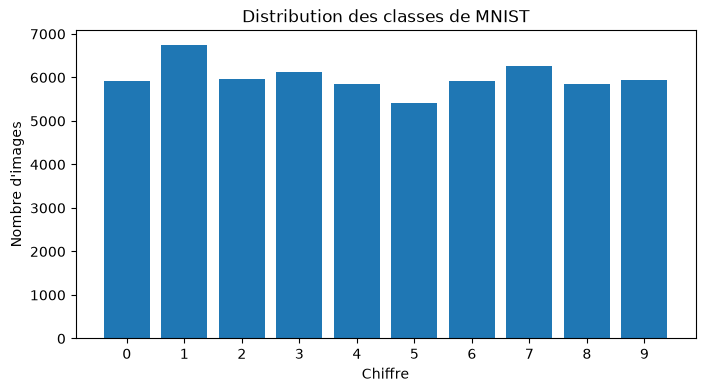

In [4]:
# 2. Distribution des chiffres
distribution = pd.Series(y_train).value_counts().sort_index()
print("\nDistribution des classes :")
print(distribution)

plt.figure(figsize=(8, 4))
plt.bar(distribution.index, distribution.values)
plt.xlabel("Chiffre")
plt.ylabel("Nombre d'images")
plt.title("Distribution des classes de MNIST")
plt.xticks(range(10))
plt.show()

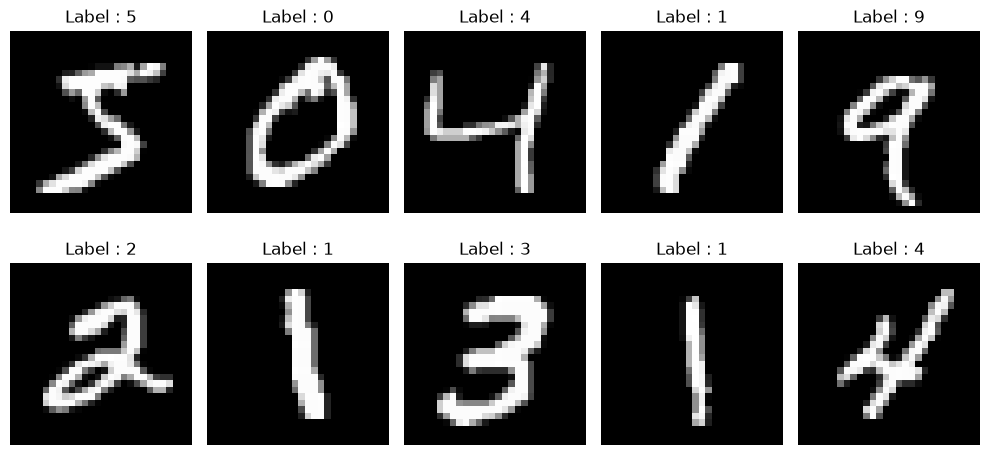

In [5]:
# 3. Visualisation de quelques images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label : {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Nettoyage des données

In [6]:
# 4. Vérification de la qualité des données
print("Valeurs manquantes :", np.isnan(X_train).sum())
print("Valeurs infinies :", np.isinf(X_train).sum())
print("Labels valides :", np.isin(y_train, range(10)).all())
print("Dimensions des images :", X_train.shape[1:])
print("Données d'entraînement finies :", np.isfinite(X_train).all())

Valeurs manquantes : 0
Valeurs infinies : 0
Labels valides : True
Dimensions des images : (28, 28)
Données d'entraînement finies : True


### Feature Engineering : statistiques par image

In [7]:
# Chaque image contient 28 × 28 = 784 pixels
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Deux caractéristiques dérivées par image
mean_intensity = X_train_flat.mean(axis=1)
std_intensity = X_train_flat.std(axis=1)

features_df = pd.DataFrame({
    "label": y_train,
    "intensite_moyenne": mean_intensity,
    "ecart_type": std_intensity
})
print("Aperçu des caractéristiques dérivées :")
display(features_df.head())

Aperçu des caractéristiques dérivées :


,label,intensite_moyenne,ecart_type
0,5,0.137680,0.312348
1,0,0.155537,0.328969
2,4,0.097254,0.257175
3,1,0.085709,0.259133
4,9,0.116116,0.291652


In [8]:
print("\nStatistiques descriptives :")
display(features_df[["intensite_moyenne", "ecart_type"]].describe())



Statistiques descriptives :


,intensite_moyenne,ecart_type
count,60000.000000,60000.000000
mean,0.130660,0.301312
std,0.043299,0.047611
min,0.025440,0.124900
25%,0.099330,0.268836
50%,0.127386,0.302826
75%,0.157873,0.334787
max,0.397574,0.467293


<Figure size 900x400 with 0 Axes>

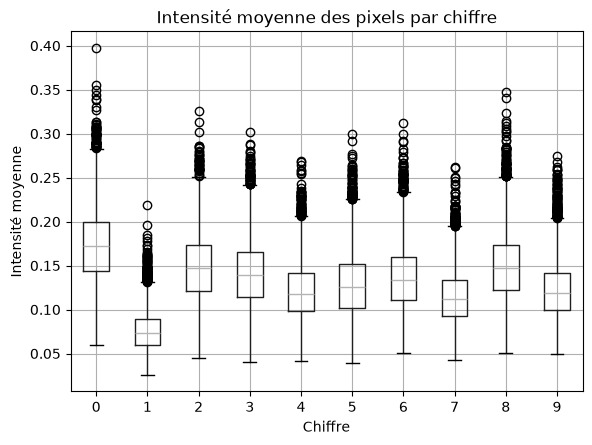

In [9]:
# Comparaison de l'intensité moyenne selon le chiffre
plt.figure(figsize=(9, 4))
features_df.boxplot(column="intensite_moyenne", by="label")
plt.title("Intensité moyenne des pixels par chiffre")
plt.suptitle("")
plt.xlabel("Chiffre")
plt.ylabel("Intensité moyenne")
plt.show()

In [10]:
ray.init(
    num_cpus=2,
    log_to_driver=False
)

2026-10-09 11:42:01,310	WARNING authentication_token_setup.py:85 -- Token authentication is enabled for this Ray cluster. Set RAY_AUTH_MODE=disabled to opt out. For more information, see https://docs.ray.io/en/latest/ray-security/token-auth.html
2026-10-09 11:42:07,895	INFO worker.py:2033 -- Started a local Ray instance.


Python version:,3.11.4
Ray version:,2.59.0


In [11]:
X_train_ref = ray.put(X_train)
y_train_ref = ray.put(y_train)

In [12]:
import tensorflow as tf
from ray import tune

def train_model(config):
    X_train = ray.get(X_train_ref)
    y_train = ray.get(y_train_ref)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(config["units"], activation="relu"),
        tf.keras.layers.Dropout(config["dropout"]),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    for epoch in range(10):
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.1,
            epochs=1,
            batch_size=config["batch_size"],
            verbose=0
        )

        tune.report({
            "accuracy": history.history["val_accuracy"][0],
            "epoch": epoch + 1
        })

In [13]:
search_space = {
    "units": tune.choice([64, 128]),
    "dropout": tune.choice([0.2, 0.3]),
    "learning_rate": tune.loguniform(1e-4, 1e-2),
    "batch_size": tune.choice([64, 128])
}

In [14]:
tuner = tune.Tuner(
    train_model,
    param_space=search_space,
    tune_config=tune.TuneConfig(num_samples=4)
)

results = tuner.fit()

2026-10-09 11:42:57,512	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\HP\AppData\Local\Temp\ray\session_2026-10-09_11-42-01_327474_15644\artifacts\2026-10-09_11-42-57\train_model_2026-10-09_11-42-57\driver_artifacts\train_model_ceefd_00000_0_batch_size=64,dropout=0.3000,learning_rate=0.0005,units=128_2026-10-09_11-42-57
2026-10-09 11:42:57,539	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\HP\AppData\Local\Temp\ray\session_2026-10-09_11-42-01_327474_15644\artifacts\2026-10-09_11-42-57\train_model_2026-10-09_11-42-57\driver_artifacts\train_model_ceefd_00000_0_batch_size=64,dropout=0.3000,learning_rate=0.0005,units=128_2026-10-09_11-42-57
2026-10-09 11:42:57,583	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Cons

In [15]:
best_result = results.get_best_result(
    metric="accuracy",
    mode="max"
)

print("Meilleurs hyperparamètres :")
for param, valeur in best_result.config.items():
    print(f"{param} : {valeur}")

print(f"\nAccuracy de validation : {best_result.metrics['accuracy']:.2%}")

Meilleurs hyperparamètres :
units : 128
dropout : 0.3
learning_rate : 0.0005241891132673827
batch_size : 64

Accuracy de validation : 97.85%


### Optimisation avec ASHA

In [16]:
from ray.tune.schedulers import ASHAScheduler

asha_scheduler = ASHAScheduler(
    metric="accuracy",
    mode="max",
    max_t=10,
    grace_period=2,
    reduction_factor=2
)

tuner_asha = tune.Tuner(
    train_model,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=6,
        scheduler=asha_scheduler,
        max_concurrent_trials=2
    )
)

results_asha = tuner_asha.fit()

2026-10-09 11:46:38,441	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\HP\AppData\Local\Temp\ray\session_2026-10-09_11-42-01_327474_15644\artifacts\2026-10-09_11-46-38\train_model_2026-10-09_11-46-38\driver_artifacts\train_model_52b7d_00000_0_batch_size=128,dropout=0.2000,learning_rate=0.0052,units=64_2026-10-09_11-46-38
2026-10-09 11:46:38,464	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\HP\AppData\Local\Temp\ray\session_2026-10-09_11-42-01_327474_15644\artifacts\2026-10-09_11-46-38\train_model_2026-10-09_11-46-38\driver_artifacts\train_model_52b7d_00000_0_batch_size=128,dropout=0.2000,learning_rate=0.0052,units=64_2026-10-09_11-46-38
2026-10-09 11:46:38,478	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Cons

### Meilleurs paramètres avec ASHA

In [20]:
best_asha = results_asha.get_best_result(
    metric="accuracy",
    mode="max"
)

print("Meilleurs hyperparamètres avec ASHA :")
for param, valeur in best_asha.config.items():
    print(f"{param} : {valeur}")

print(f"Accuracy de validation : {best_asha.metrics['accuracy']:.2%}")

Meilleurs hyperparamètres avec ASHA :
units : 64
dropout : 0.2
learning_rate : 0.0016783072808039244
batch_size : 64
Accuracy de validation : 97.62%


## Optimisation avec PBT

In [21]:
import os
import tensorflow as tf
import ray
from ray import tune
from ray.tune.schedulers import PopulationBasedTraining

class MNISTTrainable(tune.Trainable):
    def setup(self, config):
        self.X_train = ray.get(X_train_ref)
        self.y_train = ray.get(y_train_ref)
        self.epoch = 0
        self._build_model(config)

    def _build_model(self, config):
        self.model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(28, 28)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(config["units"], activation="relu"),
            tf.keras.layers.Dropout(config["dropout"]),
            tf.keras.layers.Dense(10, activation="softmax")
        ])
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

    def step(self):
        history = self.model.fit(
            self.X_train, self.y_train,
            validation_split=0.1,
            epochs=1,
            batch_size=self.config["batch_size"],
            verbose=0
        )
        self.epoch += 1
        return {
            "accuracy": float(history.history["val_accuracy"][0]),
            "training_iteration": self.epoch
        }

    def reset_config(self, new_config):
        # PBT ne modifie pas "units", donc la structure du réseau reste compatible.
        self.config = new_config
        for layer in self.model.layers:
            if isinstance(layer, tf.keras.layers.Dropout):
                layer.rate = new_config["dropout"]
        self.model.optimizer.learning_rate.assign(new_config["learning_rate"])
        return True

    def save_checkpoint(self, checkpoint_dir):
        # Ray attend que la méthode retourne le répertoire reçu.
        self.model.save_weights(os.path.join(checkpoint_dir, "model.weights.h5"))
        return checkpoint_dir

    def load_checkpoint(self, checkpoint_dir):
        self.model.load_weights(os.path.join(checkpoint_dir, "model.weights.h5"))

pbt_scheduler = PopulationBasedTraining(
    time_attr="training_iteration",
    metric="accuracy",
    mode="max",
    perturbation_interval=2,
    hyperparam_mutations={
        # On garde units fixe pour éviter une incompatibilité des poids lors d'une mutation.
        "dropout": [0.2, 0.3],
        "learning_rate": tune.loguniform(1e-4, 1e-2),
        "batch_size": [64, 128]
    }
)

pbt_tuner = tune.Tuner(
    MNISTTrainable,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=4,
        scheduler=pbt_scheduler,
        max_concurrent_trials=2
    ),
    run_config=tune.RunConfig(stop={"training_iteration": 10})
)

results_pbt = pbt_tuner.fit()

# Vérifier que les trials ont terminé sans erreur avant d'interpréter le résultat.
for trial in results_pbt:
    print(trial, "| erreur:", trial.error is not None)


2026-10-09 11:55:25,578	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\HP\AppData\Local\Temp\ray\session_2026-10-09_11-42-01_327474_15644\artifacts\2026-10-09_11-55-25\MNISTTrainable_2026-10-09_11-55-25\driver_artifacts\MNISTTrainable_8ceac_00000_0_batch_size=128,dropout=0.3000,learning_rate=0.0002,units=128_2026-10-09_11-55-25
2026-10-09 11:55:25,596	WARNING trial.py:644 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\HP\AppData\Local\Temp\ray\session_2026-10-09_11-42-01_327474_15644\artifacts\2026-10-09_11-55-25\MNISTTrainable_2026-10-09_11-55-25\driver_artifacts\MNISTTrainable_8ceac_00000_0_batch_size=128,dropout=0.3000,learning_rate=0.0002,units=128_2026-10-09_11-55-25
2026-10-09 11:55:25,608	WARNING trial.py:644 -- The path to the trial log directory is too long (max len

Result(
  metrics={'accuracy': 0.9769999980926514},
  path='C:/Users/HP/ray_results/MNISTTrainable_2026-10-09_11-55-25/MNISTTrainable_8ceac_00000_0_batch_size=128,dropout=0.3000,learning_rate=0.0002,units=128_2026-10-09_11-55-25',
  filesystem='local',
  checkpoint=Checkpoint(filesystem=local, path=C:/Users/HP/ray_results/MNISTTrainable_2026-10-09_11-55-25/MNISTTrainable_8ceac_00000_0_batch_size=128,dropout=0.3000,learning_rate=0.0002,units=128_2026-10-09_11-55-25/checkpoint_000004)
) | erreur: False
Result(
  metrics={'accuracy': 0.9674999713897705},
  path='C:/Users/HP/ray_results/MNISTTrainable_2026-10-09_11-55-25/MNISTTrainable_8ceac_00001_1_batch_size=128,dropout=0.2000,learning_rate=0.0002,units=64_2026-10-09_11-55-25',
  filesystem='local',
  checkpoint=Checkpoint(filesystem=local, path=C:/Users/HP/ray_results/MNISTTrainable_2026-10-09_11-55-25/MNISTTrainable_8ceac_00001_1_batch_size=128,dropout=0.2000,learning_rate=0.0002,units=64_2026-10-09_11-55-25/checkpoint_000003)
) | erre

### Meilleurs paramètre avec PBT

In [22]:
best_pbt = results_pbt.get_best_result(metric="accuracy", mode="max")
print("Meilleurs hyperparamètres avec PBT :")
for param, valeur in best_pbt.config.items():
    print(f"{param} : {valeur}")
print(f"Accuracy de validation : {best_pbt.metrics['accuracy']:.2%}")


Meilleurs hyperparamètres avec PBT :
units : 128
dropout : 0.3
learning_rate : 0.00016255672061057596
batch_size : 128
Accuracy de validation : 97.70%


### Comparaison des résultats

,Méthode,Accuracy validation (%),Durée du meilleur trial (s),Unités,Dropout,Learning rate,Batch size
0,Recherche de base,97.85,104.52,128,0.3,0.000524,64
1,ASHA,97.62,81.05,64,0.2,0.001678,64
2,PBT,97.70,163.30,128,0.3,0.000163,128


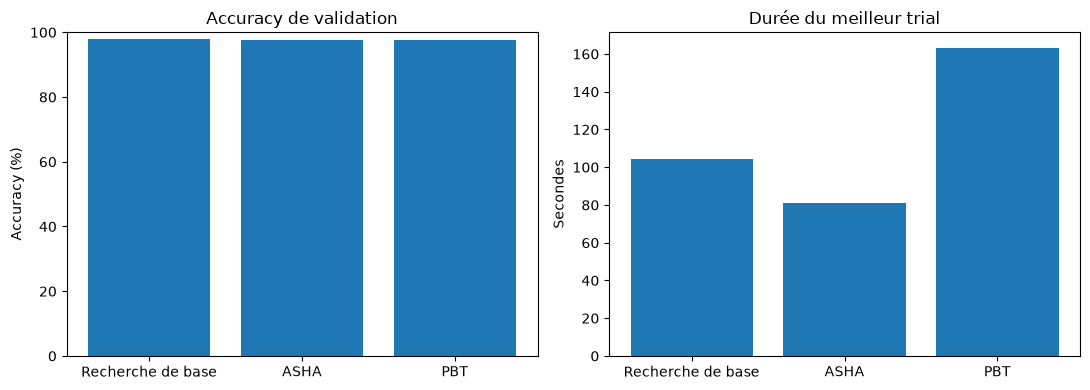

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

def extraire_resultat(nom, resultats):
    meilleur = resultats.get_best_result(metric="accuracy", mode="max")
    return {
        "Méthode": nom,
        "Accuracy validation (%)": round(float(meilleur.metrics["accuracy"]) * 100, 2),
        "Durée du meilleur trial (s)": round(float(meilleur.metrics.get("time_total_s", 0)), 2),
        "Unités": meilleur.config["units"],
        "Dropout": meilleur.config["dropout"],
        "Learning rate": float(meilleur.config["learning_rate"]),
        "Batch size": meilleur.config["batch_size"]
    }

comparaison = pd.DataFrame([
    extraire_resultat("Recherche de base", results),
    extraire_resultat("ASHA", results_asha),
    extraire_resultat("PBT", results_pbt)
])
display(comparaison)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparaison["Méthode"], comparaison["Accuracy validation (%)"])
axes[0].set_title("Accuracy de validation")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
axes[1].bar(comparaison["Méthode"], comparaison["Durée du meilleur trial (s)"])
axes[1].set_title("Durée du meilleur trial")
axes[1].set_ylabel("Secondes")
plt.tight_layout()
plt.show()


### Évaluation finale sur le jeu de test

In [24]:
# On réentraîne un nouveau modèle avec les meilleurs hyperparamètres de la recherche de base.
config_final = best_result.config

modele_final = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(config_final["units"], activation="relu"),
    tf.keras.layers.Dropout(config_final["dropout"]),
    tf.keras.layers.Dense(10, activation="softmax")
])
modele_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=config_final["learning_rate"]),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modele_final.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=config_final["batch_size"],
    verbose=1
)
loss_test, accuracy_test = modele_final.evaluate(X_test, y_test, verbose=0)
print(f"Loss sur le jeu de test : {loss_test:.4f}")
print(f"Accuracy sur le jeu de test : {accuracy_test:.2%}")


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8616 - loss: 0.4803 - val_accuracy: 0.9487 - val_loss: 0.1903
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9292 - loss: 0.2449 - val_accuracy: 0.9603 - val_loss: 0.1419
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9451 - loss: 0.1899 - val_accuracy: 0.9687 - val_loss: 0.1120
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9542 - loss: 0.1560 - val_accuracy: 0.9725 - val_loss: 0.0978
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9601 - loss: 0.1344 - val_accuracy: 0.9762 - val_loss: 0.0877
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9633 - loss: 0.1203 - val_accuracy: 0.9773 - val_loss: 0.0789
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9691 - loss: 0.1068 - val_accuracy: 0.9770 - val_loss: 0.0778
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9709 - loss: 0.0969 - val_a